In [1]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import matplotlib.pyplot as plt

import deeplay as dl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [2]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


In [3]:
data = np.load('D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)

In [4]:
data.keys()

KeysView(NpzFile 'D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz' with keys: E, q, t, n)

In [5]:
index_min = 1000
index_max = 1200

E = data['E'][index_min:index_max]
Q = data['q'][index_min:index_max]

In [6]:
from skimage.restoration import unwrap_phase

In [7]:
phases = np.stack([unwrap_phase(np.angle(E[i])) for i in range(E.shape[0])])

In [8]:
# Pad  with zeros to make it square
max_size = max(phases.shape[1], phases.shape[2])
diff_size = np.abs(phases.shape[1] - phases.shape[2])
if phases.shape[2] < phases.shape[1]:
    phases = np.pad(phases, ((0, 0), (0, 0), (diff_size // 2, diff_size // 2)), mode='constant')
    E = np.pad(E, ((0, 0), (0, 0), (diff_size // 2, diff_size // 2)), mode='constant')
else:
    phases = np.pad(phases, ((0, 0), (diff_size // 2, diff_size // 2), (0, 0)), mode='constant')
    E = np.pad(E, ((0, 0), (diff_size // 2, diff_size // 2), (0, 0)), mode='constant')

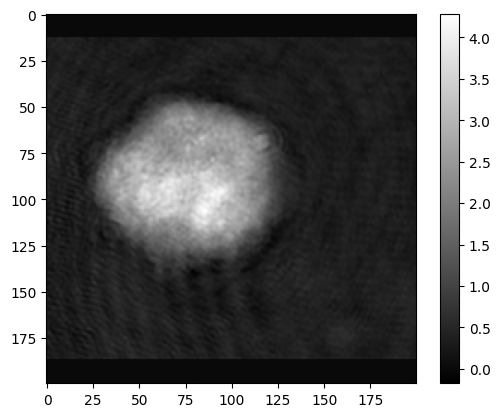

In [9]:
plt.imshow(phases[0], cmap='gray')
plt.colorbar()

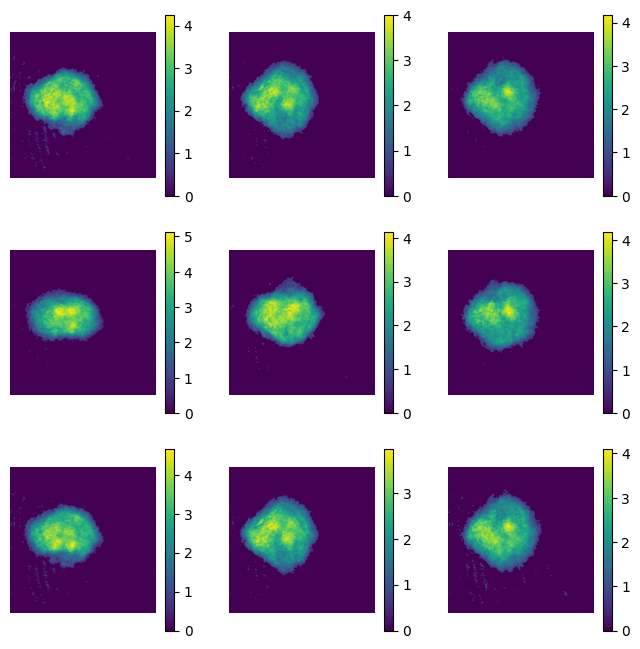

In [10]:
# 3x3 grid of 9 projections in a row
th=0.57
plt.figure(figsize=(8, 8))
for i in range(9):

    #Set values below th to zero
    proj_upd = phases[np.random.randint(0, phases.shape[0])]

    proj_upd[proj_upd < th] = 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')

In [11]:
projs = []
for i, proj in enumerate(phases):

    proj_upd = proj.copy()
    proj_upd[proj_upd < th] = 0
    projs.append(proj_upd)

projs = np.stack(projs)


In [12]:
projs = torch.tensor(projs).unsqueeze(1).to(DEV).float()
projs.shape

torch.Size([200, 1, 200, 200])

In [13]:
from tomodpdt import helpers

handler = helpers.MaskRCNNHandler()

frames, est_xy = helpers.track_and_centralize(frames=projs, maskrcnn=handler)

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


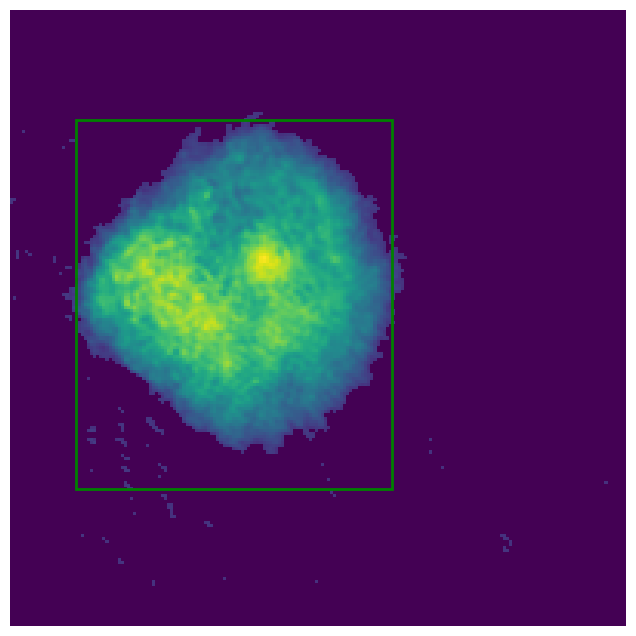

In [14]:
# Run prediction
masks, boxes, center = handler.predict(projs[50])

# Show results
handler.show_results(projs[50, 0], masks, boxes)

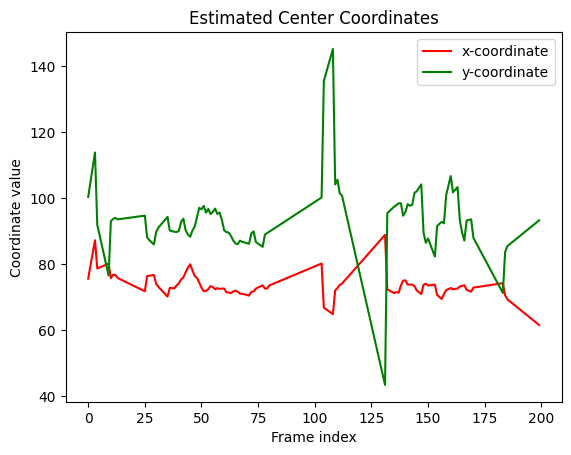

In [15]:
plt.plot(est_xy[:, 0], 'r-', label='x-coordinate')
plt.plot(est_xy[:, 1], 'g-', label='y-coordinate')
plt.xlabel('Frame index')
plt.ylabel('Coordinate value')
plt.title('Estimated Center Coordinates')
plt.legend()
plt.show()

In [16]:
# Set outliers to the mean of the full trajectory
mean_xy = np.median(est_xy, axis=0)
est_xy[est_xy[:, 0] < mean_xy[0]*0.75, 0] = mean_xy[0]
est_xy[est_xy[:, 0] > mean_xy[0]*1.25, 0] = mean_xy[0]

est_xy[est_xy[:, 1] < mean_xy[1]*0.75, 1] = mean_xy[1]
est_xy[est_xy[:, 1] > mean_xy[1]*1.25, 1] = mean_xy[1]

Text(0.5, 1.0, 'Estimated Center Coordinates (Outliers Removed)')

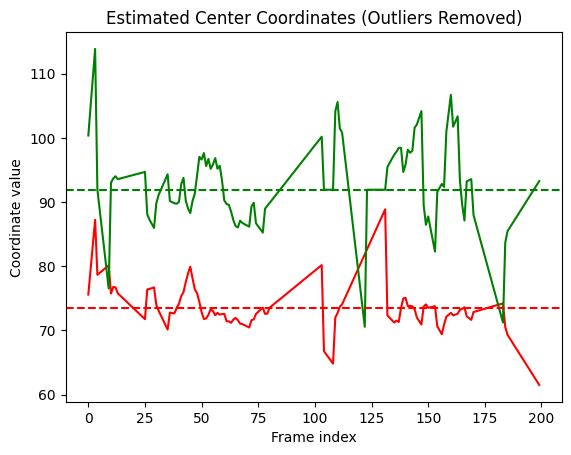

In [17]:
plt.plot(est_xy[:, 0], 'r-', label='x-coordinate')
plt.plot(est_xy[:, 1], 'g-', label='y-coordinate')
plt.axhline(mean_xy[0], color='r', linestyle='--', label='Mean x-coordinate')
plt.axhline(mean_xy[1], color='g', linestyle='--', label='Mean y-coordinate')
plt.xlabel('Frame index')
plt.ylabel('Coordinate value')
plt.title('Estimated Center Coordinates (Outliers Removed)')

In [18]:
import cv2

def centralize_frame(frame, x, y):
    h, w = frame.shape[:2]

    # Calculate shift required to move (x, y) to (w/2, h/2)
    shift_x = (w / 2) - x
    shift_y = (h / 2) - y

    # Apply shift to the entire frame with a constant border (black)
    M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
    centralized_frame = cv2.warpAffine(frame, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    return centralized_frame

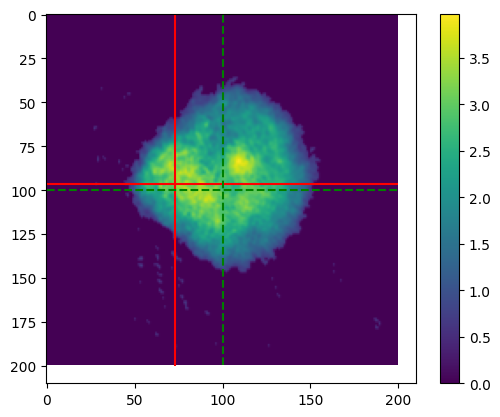

In [19]:
c_frame = centralize_frame(projs[50, 0].cpu().numpy(), est_xy[50][0], est_xy[50][1])
plt.imshow(c_frame)
plt.vlines(est_xy[50][0], 0, c_frame.shape[0], color='r')
plt.hlines(est_xy[50][1], 0, c_frame.shape[1], color='r')

plt.vlines(c_frame.shape[1] // 2, 0, c_frame.shape[0], color='g', linestyle='--')
plt.hlines(c_frame.shape[0] // 2, 0, c_frame.shape[1], color='g', linestyle='--')

plt.colorbar()

In [20]:
median_xy = np.median(est_xy, axis=0)

In [21]:
aligned_phases = []
median_align = True
for i in range(projs.shape[0]):
    if median_align:
        # Use median coordinates for alignment
        x, y = median_xy
    else:
        # Use estimated coordinates for alignment
        x, y = est_xy[i]
    c_frame = centralize_frame(projs[i, 0].cpu().numpy(), x, y)

    
    aligned_phases.append(c_frame)
aligned_phases = np.stack(aligned_phases)

In [22]:
E_upd = E.copy()

In [23]:
def correctfield(field, n_iter=5):
    """
    Correct field
    """

    if field.dtype == torch.float32:
        field = field.to(torch.complex64)

    f_new = field.clone()

    # Normalize with mean of absolute value.
    f_new = f_new / torch.mean(torch.abs(f_new))

    for _ in range(n_iter):
        f_new = f_new * torch.exp(-1j * torch.median(torch.angle(f_new)))

    return f_new

In [24]:
E = correctfield(torch.tensor(E_upd, device=DEV, dtype=torch.complex64), n_iter=5).cpu().numpy()

In [25]:
E_upd = E.copy()
for i in range(E_upd.shape[0]):
    tmp = aligned_phases[i]
    
    # Set values below threshold to 1
    mask = tmp < th


    real_part = np.real(E_upd[i])
    imag_part = np.imag(E_upd[i])

    # Align them using estimated center coordinates
    if median_align:
        # Use median coordinates for alignment
        x, y = median_xy
    else:
        # Use estimated coordinates for alignment
        x, y = est_xy[i]
        
    real_part = centralize_frame(real_part, x, y)
    imag_part = centralize_frame(imag_part, x, y)

    # Combine real and imaginary parts back into a complex field
    E_upd[i] = real_part + 1j * imag_part

    # Set values below threshold to 1
    E_upd[i][mask] = 1 

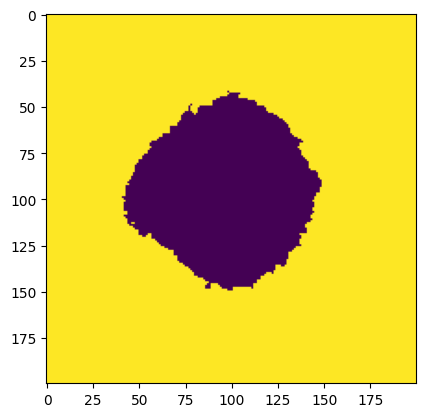

In [26]:
plt.imshow(mask)

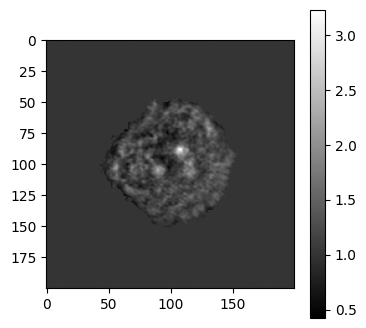

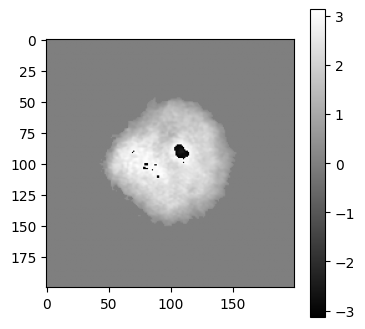

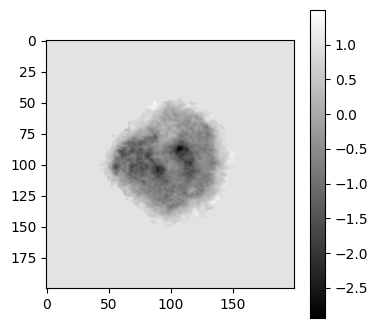

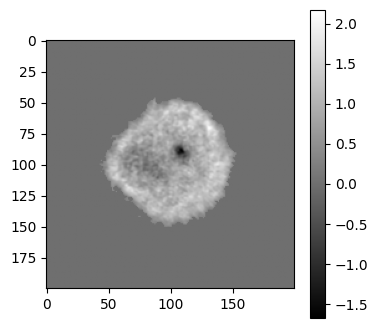

In [27]:
plt.figure(figsize=(4, 4))
plt.imshow(np.abs(E_upd[70]), cmap='gray')
plt.colorbar()
plt.figure(figsize=(4, 4))
plt.imshow(np.angle(E_upd[70]), cmap='gray')
plt.colorbar()
plt.figure(figsize=(4, 4))
plt.imshow(np.real(E_upd[70]), cmap='gray')
plt.colorbar()
plt.figure(figsize=(4, 4))
plt.imshow(np.imag(E_upd[70]), cmap='gray')
plt.colorbar()

In [28]:
E = E_upd

In [29]:
N = 128

In [30]:
pad_x, pad_y = (E.shape[1]- N) // 2, (E.shape[2] - N) // 2
E = E[:, pad_x:pad_x + N, pad_y:pad_y + N]

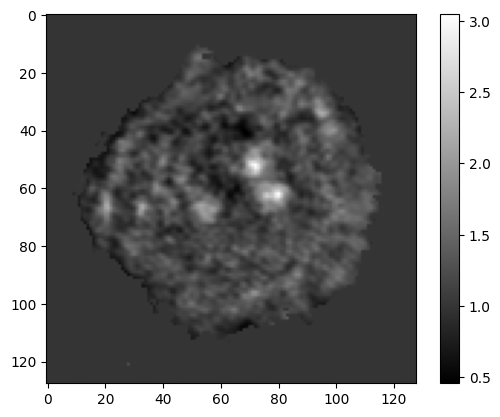

In [31]:
plt.imshow(np.abs(E[80]), cmap='gray')
plt.colorbar()

In [32]:
# Make 2 channels for imag and real part
E = np.stack([np.real(E), np.imag(E)], axis=1)

In [33]:
E.shape

(200, 2, 128, 128)

In [34]:
np.min(np.abs(E))

0.0

In [35]:
projections = torch.tensor(E, dtype=torch.float32).to(DEV)

In [36]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# Setup the optics
optics_setttings = setup_optics(
        nsize=N, 
        padding_xy=N//2, 
        microscopy_regime='Brightfield', 
        NA=1.15, 
        wavelength=640e-9, 
        resolution=200e-9, 
        magnification=1, 
        return_field=True)

# Generate the imaging model
brightfield_model = imaging_model(optics_setup=optics_setttings)

In [37]:
q_new = Q.copy()

q_new[...,1] = Q[...,2]
q_new[...,2] = Q[...,3]
q_new[...,3] = Q[...,1]


In [38]:
# Create the tomographic_model
tomographic_model = tomodpdt.Tomography(
    volume_size=(N, N, N), # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='quaternion', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model,
    translation_maxmin=8, # The maximum and minimum translation
    )

In [39]:
# Initialize the parameters
tomographic_model.initialize_parameters(projections, normalize=False, initial_frames_per_rotation=150, max_epochs=100)

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name                | Type                 | Params | Mode 
---------------------------------------------------------------------
0 | encoder             | Sequential           | 80.1 K | train
1 | fc_mu               | MultiLayerPerceptron | 131 K 

Epoch 99: 100%|██████████| 7/7 [00:00<00:00, 30.12it/s, v_num=450, train_rec_loss_step=0.0907, train_KL_step=62.70, train_total_loss_step=0.0914, train_rec_loss_epoch=0.0866, train_KL_epoch=238.0, train_total_loss_epoch=0.089]  


For vizualisation we initialize a `TomoPlotter` class.

In [40]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)


Using the VAE, we can visualize the **latent space** over time, revealing a trajectory that captures the system’s dynamics. Notably, **rotational movements** appear as transitions in this space, showing how the model encodes changes in orientation.


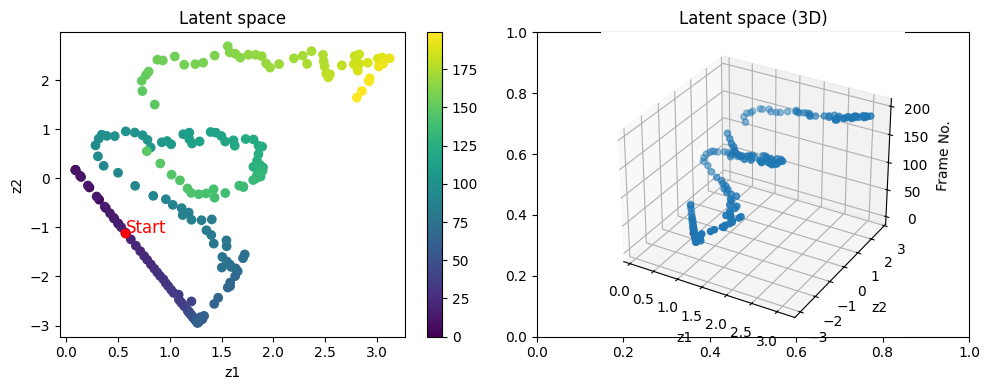

In [41]:
plotter.plot_latent_space()

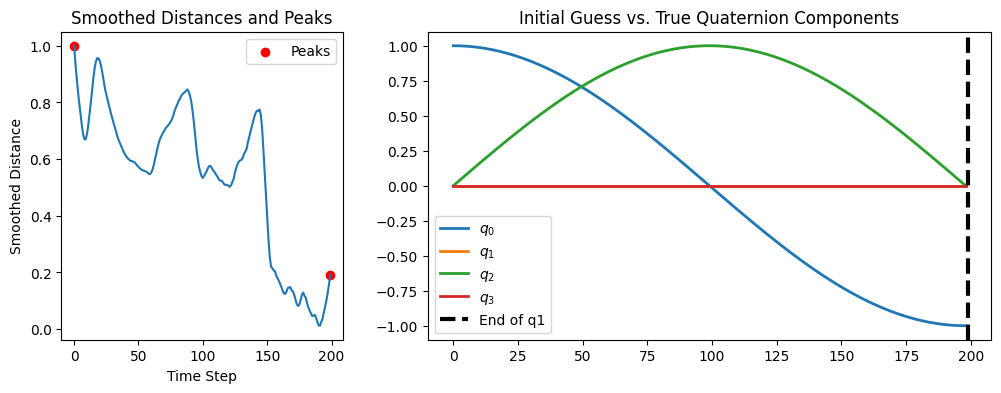

In [42]:
plotter.plot_smooth_dist_intial_guess()

To further validate the VAE, we compare reconstructed frames to the originals and observe a strong visual similarity.

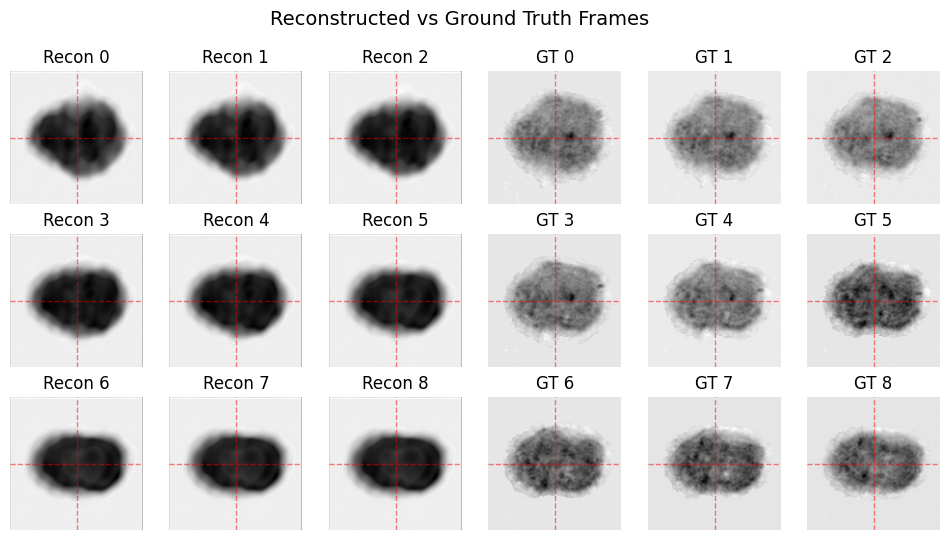

In [43]:
plotter.plot_reconstructed_vs_gt()

In [44]:
#tomographic_model.rotation_params = torch.nn.Parameter(torch.tensor(q_new[:len(tomographic_model.rotation_params)]))

# 
#tomographic_model.volume = torch.nn.Parameter(torch.tensor(volume).to(DEV))

In [45]:
#np.save('test_optics/volume_init4.npy', tomographic_model.volume.cpu().detach().numpy())

#volume = np.load('test_optics/volume_init4.npy')
#tomographic_model.volume = torch.nn.Parameter(torch.tensor(volume).to(DEV, dtype=torch.float32))
#tomographic_model.volume.requires_grad = True

### 3.3 - Optimize the volume alone first

As outline in the main section, it is now time to proceede with the actual 3D-reconstruction optimization.

The optimization process flows more effectively when an initial 3D volume is optimized first. To achieve this, the volume is optimized for a few iterations before both the volume and rotation parameters are jointly optimized. While it is possible to provide a custom initial volume to begin the optimization, in this case, we start with a fixed volume value of 1.33.

In [46]:
N1 = len(tomographic_model.frames) # Number of frames
idx = torch.arange(N1) # Index of frames
epochs_object_only = 3 # Number of epochs for the object only optimization
rotation_only = 5
batch_size_object_only = 16 # Batch size for the object only optimization

train the model for `epochs_object_only` epochs...

In [47]:
#tomographic_model.volume = nn.Parameter(torch.tensor(volume, dtype=torch.float32).to(DEV)-1.33)

In [ ]:
# Move the model to device
tomographic_model.move_all_to_device(DEV)

it = 50 # Number of iterations for the training loop

# Train the model
for i in range(it):
    print(f"Iteration {i+1} of {it}")

    # First stage: optimize the volume only
    trainer = dl.Trainer(max_epochs=epochs_object_only, accelerator="auto", log_every_n_steps=10, enable_model_summary=False)

    # Toggle gradients for the volume
    tomographic_model.toggle_gradients_quaternion(False)
    tomographic_model.toggle_gradients_translation(False)
    tomographic_model.toggle_gradients_volume(True)

    start_time = time.time()
    trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only, shuffle=True))
    print("Training time: ", (time.time() - start_time) / 60, " minutes")

    # Second stage: optimize the translation and quaternion parameters
    trainer2 = dl.Trainer(max_epochs=rotation_only, accelerator="auto", log_every_n_steps=10, enable_model_summary=False)

    tomographic_model.toggle_gradients_quaternion(True)
    tomographic_model.toggle_gradients_translation(True)
    tomographic_model.toggle_gradients_volume(False)

    start_time = time.time()
    trainer2.fit(tomographic_model, DataLoader(idx, batch_size=N1//5, shuffle=False))
    print("Training time: ", (time.time() - start_time) / 60, " minutes") 


Iteration 1 of 50
Epoch 2: 100%|██████████| 13/13 [00:17<00:00,  0.75it/s, v_num=451, train_total_loss_step=2.790, train_proj_loss_step=2.730, train_latent_loss_step=0.00882, train_rtv_loss_step=0.00048, train_so_loss_step=0.0443, train_total_loss_epoch=3.340, train_proj_loss_epoch=3.290, train_latent_loss_epoch=0.0104, train_rtv_loss_epoch=0.000414, train_so_loss_epoch=0.0392]
Training time:  0.8641626318295796  minutes


c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 4: 100%|██████████| 6/6 [00:29<00:00,  0.20it/s, v_num=452, train_total_loss_step=3.090, train_proj_loss_step=3.040, train_latent_loss_step=0.0168, train_qv_loss_step=3.06e-5, train_rtr_loss_step=0.00195, train_total_loss_epoch=3.000, train_proj_loss_epoch=2.930, train_latent_loss_epoch=0.00982, train_qv_loss_epoch=0.000193, train_rtr_loss_epoch=0.00273, train_q0_loss_step=0.000633, train_rtr_trans_loss_step=0.0329, train_q0_loss_epoch=0.000633, train_rtr_trans_loss_epoch=0.0572]  
Training time:  2.367864727973938  minutes
Iteration 2 of 50
Epoch 2: 100%|██████████| 13/13 [00:17<00:00,  0.73it/s, v_num=453, train_total_loss_step=2.350, train_proj_loss_step=2.330, train_latent_loss_step=0.0112, train_rtv_loss_step=0.000961, train_so_loss_step=0.0121, train_total_loss_epoch=2.320, train_proj_loss_epoch=2.300, train_latent_loss_epoch=0.0103, train_rtv_loss_epoch=0.000882, train_so_loss_epoch=0.0165] 
Training time:  0.8947277347246806  minutes
Epoch 4: 100%|██████████| 6/6 [00:29<0

In [ ]:
# Clear the GPU memory
torch.cuda.empty_cache()

### 3.4 - Optimize the 3D volume and the rotation parameters

This is the main optimization loop, where both the 3D volume and rotation parameters are optimized simultaneously. It mirrors the earlier procedure, but now gradients for the rotation parameters are enabled.

In [ ]:
epochs_object_rot = 5 # Number of epochs for the object and rotation optimization
batch_size_object_rot = 64 # Batch size for the object and rotation optimization

and train the model for `epochs_object_rot` epochs...

In [ ]:
# Toggle the gradients of the quaternion parameters
#tomographic_model.toggle_gradients_quaternion(False)

# Move the model to device
#tomographic_model.move_all_to_device(DEV)

# Train the model
#start_time = time.time()
#trainer = dl.Trainer(max_epochs=epochs_object_rot, accelerator="auto", log_every_n_steps=10)
#trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_rot, shuffle=False))
#print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
#try:
#    trainer.history.plot()
#except:
#    print("No history to plot...")

## 4.0 - Visualize the reconstructed volume and the parameters

Finally, we visualize the reconstructed 3D volume and the rotation parameters. The reconstructed volume is displayed as a 3D volume, while the rotation parameters are represented in a 3D scatter plot.

In [ ]:
# Clear the GPU memory
torch.cuda.empty_cache()

In [ ]:
# Move it to the GPU if possible for faster plotting
tomographic_model.move_all_to_device(DEV)

# Visualize the final volume and rotations.
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

By visualizing summation views of the 3D object along the x, y, and z axes, we can assess how well the optimized volume matches the ground truth.

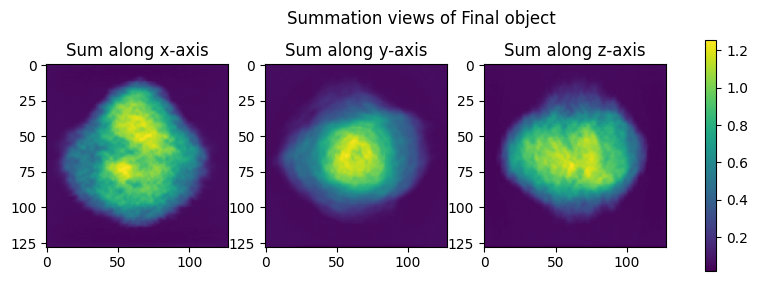

In [ ]:
plotter.plot_sum_object(save_name="Final object")

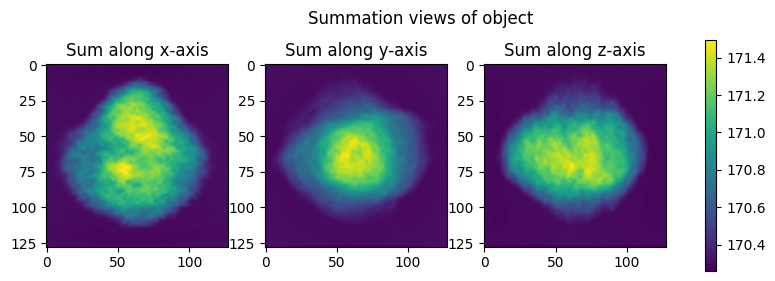

In [ ]:
vol = tomographic_model.volume.cpu().detach().numpy()
tomodpdt.plotting.plot_sum_object(vol+1.33)


In [ ]:
test = torch.zeros_like(tomographic_model.volume) + 1e-3

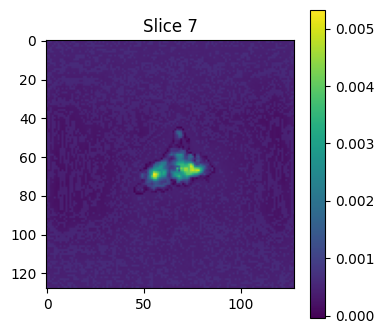

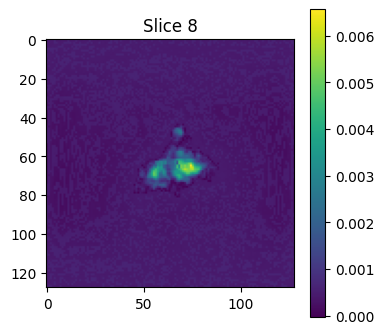

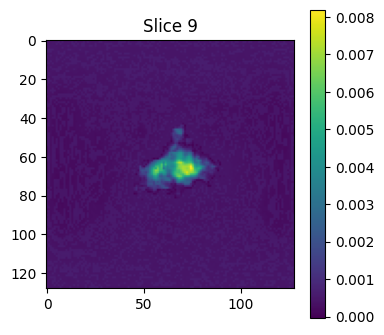

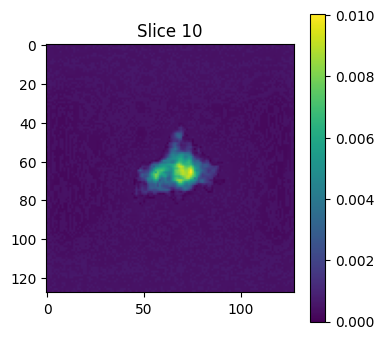

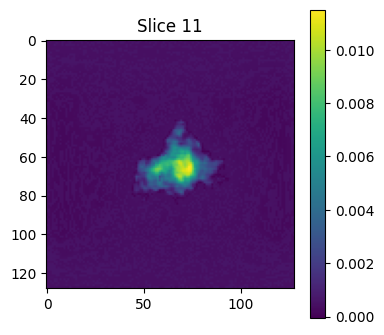

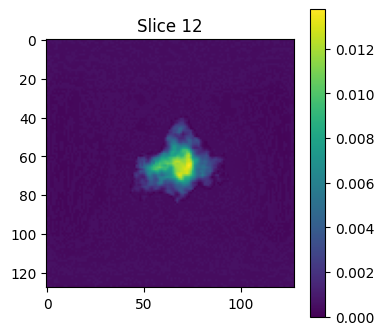

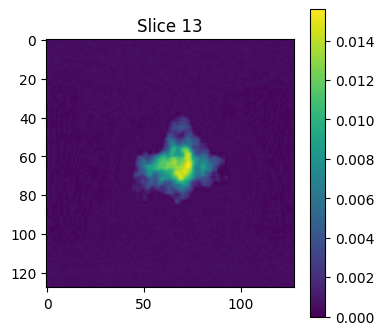

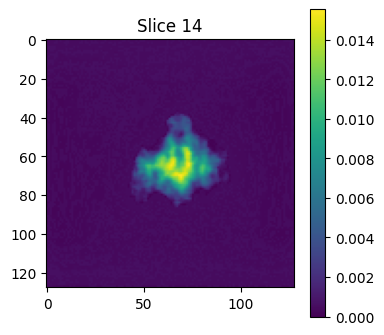

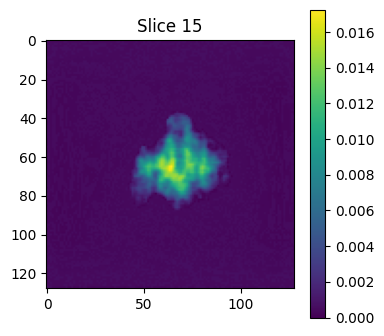

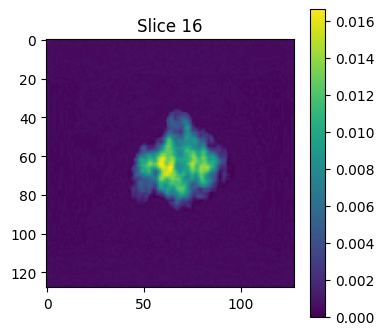

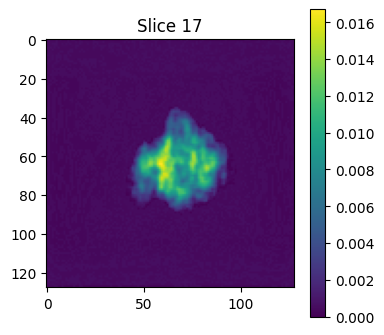

In [ ]:
count=0
for i in range(0, vol.shape[0]):
    if np.max(vol[:, :, i]) < 0.005:
        continue
    else:
        count += 1
    plt.figure(figsize=(4, 4))
    plt.imshow(vol[:, :, i])
    plt.colorbar()
    plt.title(f'Slice {i}')
    plt.show()

    if count > 10:
        break


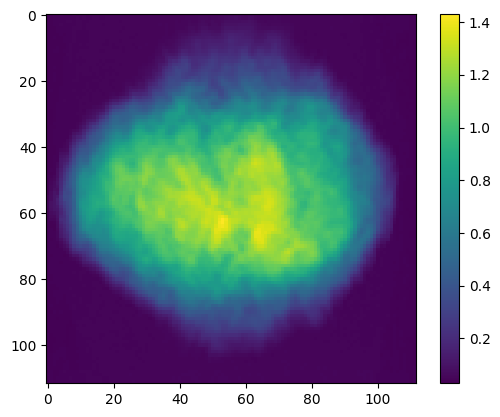

In [ ]:
crop = 8
plt.imshow(tomographic_model.volume[crop:-crop, crop:-crop, crop:-crop].detach().cpu().sum(2))
plt.colorbar()

In [ ]:
#tomodpdt.plotting.visualize_3d_volume(
#    tomographic_model.volume.cpu().detach().numpy(), 
#)

Instead of summation views, we can visualize the forward projections of the reconstructed object and compare them to the ground truth 2D frames. The similarity indicates a successful reconstruction.

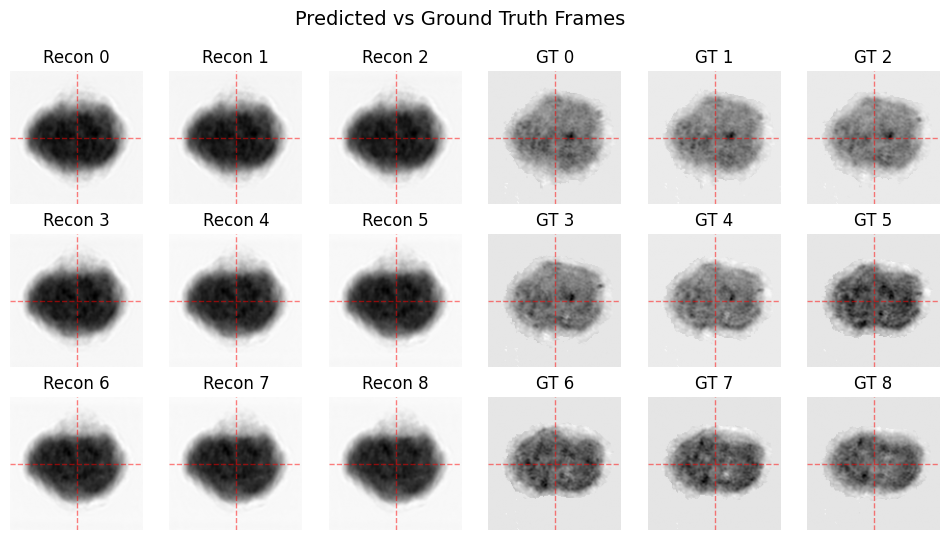

In [ ]:
plotter.plot_reconstructed_vs_gt(column_headers=["Predicted", "Ground Truth"], forward=True, save_name="Reconstructed vs GT")

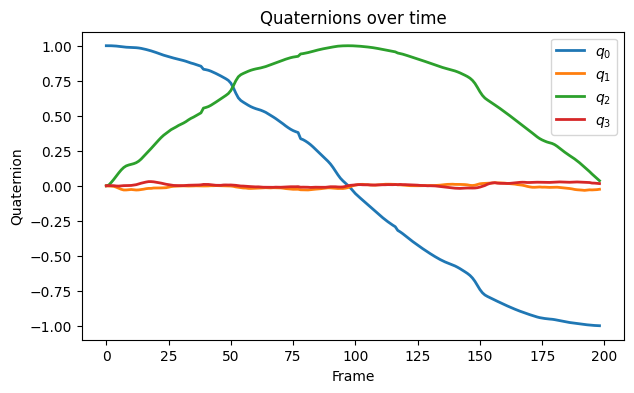

In [ ]:
plotter.plot_quaternions()

In [ ]:
qq = torch.tensor(q_new[:len(tomographic_model.rotation_params)]).cpu().detach().numpy()

# Normalize so the first quaternion is [1, 0, 0, 0] and the rest are relative to it




In [ ]:
import torch

def quat_inverse(q):
    # q is (..., 4) quaternion
    w, x, y, z = q.unbind(-1)
    return torch.stack([w, -x, -y, -z], dim=-1) / q.norm(dim=-1, keepdim=True)**2

def quat_multiply(q1, q2):
    # Hamilton product
    w1, x1, y1, z1 = q1.unbind(-1)
    w2, x2, y2, z2 = q2.unbind(-1)
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    return torch.stack([w, x, y, z], dim=-1)

quats = torch.tensor(qq, dtype=torch.float32)
q0_inv = quat_inverse(quats[0])
relative_quats = quat_multiply(q0_inv, quats)

In [ ]:
qq_pred = tomographic_model.get_quaternions_final()
qq_pred = qq_pred.cpu().detach().numpy()

In [ ]:
qq_init = tomographic_model.rotation_initial_dict['quaternions'].cpu().detach().numpy()

In [ ]:
qq_init.shape

(199, 4)

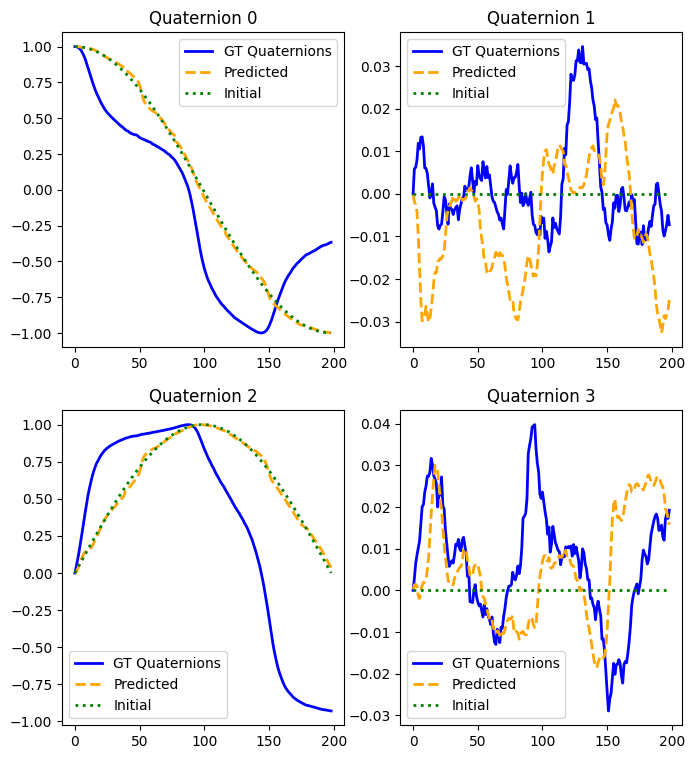

In [ ]:
plt.figure(figsize=(8, 9))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.plot(relative_quats[:,i], label='GT Quaternions', linewidth=2, color='blue')
    plt.plot(qq_pred[:,i], label='Predicted', linestyle='--', linewidth=2, color='orange')
    plt.plot(qq_init[:,i], label='Initial', linestyle=':', linewidth=2, color='green')
    plt.title(f'Quaternion {i}')
    plt.legend()

In [ ]:
idx = np.random.randint(0, len(tomographic_model.rotation_params), 10)

In [ ]:
forward_projections = tomographic_model.full_forward_final(max_projections=10, idx=idx)

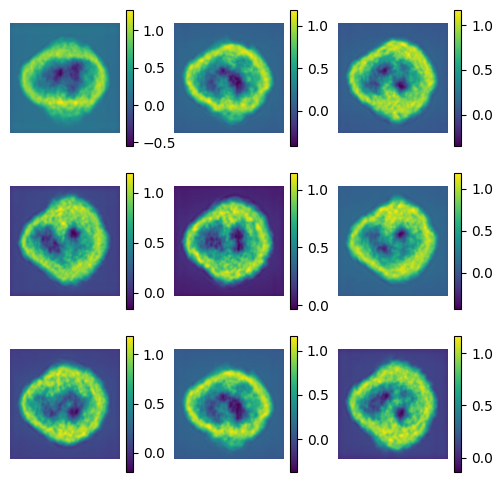

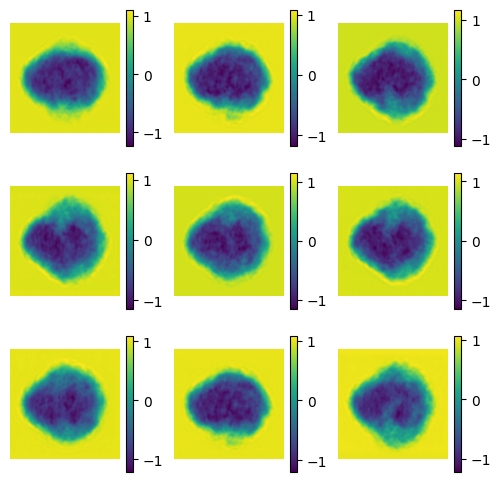

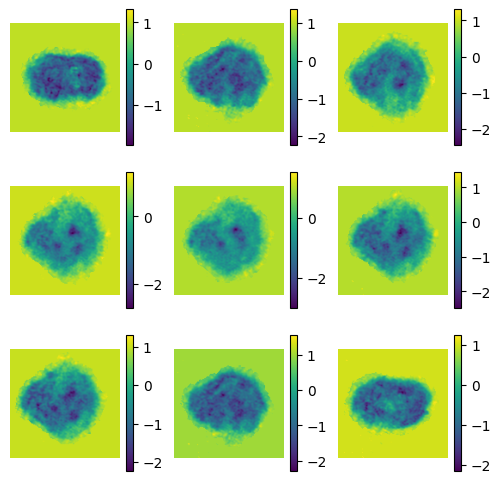

In [ ]:
plt.figure(figsize=(6, 6))
for i in range(9):
    #Set values below th to zero
    proj_upd = forward_projections[i, 1].detach().cpu().numpy()

    #proj_upd[proj_upd < th] = 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
for i in range(9):
    #Set values below th to zero
    proj_upd = forward_projections[i, 0].detach().cpu().numpy()

    #proj_upd[proj_upd < th] = 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

# show projections
plt.figure(figsize=(6, 6))
for i, idx_ in enumerate(idx):
    if i >= 9:
        break
    proj_upd = tomographic_model.frames[idx_].detach().cpu().numpy()
    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd[0])
    plt.colorbar()
    plt.axis('off')
plt.show()

Text(0.5, 0, 'Frame index')

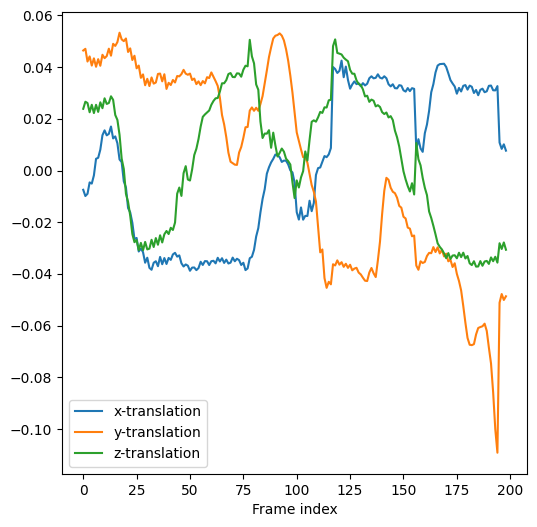

In [ ]:
tt =  tomographic_model.get_translations_final()

plt.figure(figsize=(6, 6))
plt.plot(tt[:, 0].detach().cpu().numpy(), label='x-translation')
plt.plot(tt[:, 1].detach().cpu().numpy(), label='y-translation')
plt.plot(tt[:, 2].detach().cpu().numpy(), label='z-translation')
plt.legend()
plt.xlabel('Frame index')